In [11]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# the Neural network calss import 
from neural import NeuralNetwork

In [12]:
df = pd.read_csv('Data2/clean_train_data.csv') 
df['Price'] = df.pop('Price') 
df.info()
df.head()
X = df.drop('Price', axis=1)
y = df['Price']

X

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5811 entries, 0 to 5810
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Kilometers_Driven          5811 non-null   int64  
 1   Mileage                    5811 non-null   float64
 2   Engine                     5811 non-null   float64
 3   Power                      5811 non-null   float64
 4   Seats                      5811 non-null   float64
 5   Age                        5811 non-null   int64  
 6   Fuel_Type_CNG              5811 non-null   bool   
 7   Fuel_Type_Diesel           5811 non-null   bool   
 8   Fuel_Type_LPG              5811 non-null   bool   
 9   Fuel_Type_Petrol           5811 non-null   bool   
 10  Transmission_Automatic     5811 non-null   bool   
 11  Transmission_Manual        5811 non-null   bool   
 12  Owner_Type_First           5811 non-null   bool   
 13  Owner_Type_Fourth & Above  5811 non-null   bool 

,Kilometers_Driven,Mileage,Engine,Power,Seats,Age,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Owner_Type_First,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third
0,72000,26.60,998.0,58.16,5.0,16,True,False,False,False,False,True,True,False,False,False
1,41000,19.67,1582.0,126.20,5.0,11,False,True,False,False,False,True,True,False,False,False
2,46000,18.20,1199.0,88.70,5.0,15,False,False,False,True,False,True,True,False,False,False
3,87000,20.77,1248.0,88.76,7.0,14,False,True,False,False,False,True,True,False,False,False
4,40670,15.20,1968.0,140.80,5.0,13,False,True,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5806,27365,28.40,1248.0,74.00,5.0,12,False,True,False,False,False,True,True,False,False,False
5807,100000,24.40,1120.0,71.00,5.0,11,False,True,False,False,False,True,True,False,False,False
5808,55000,14.00,2498.0,112.00,8.0,14,False,True,False,False,False,True,False,False,True,False
5809,46000,18.90,998.0,67.10,5.0,13,False,False,False,True,False,True,True,False,False,False


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 4648
Test set size: 1163


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled

array([[-0.5292184 ,  0.0723422 , -0.70679948, ..., -0.035952  ,
        -0.43933869, -0.13891813],
       [ 0.25756611,  0.18367843, -0.70679948, ..., -0.035952  ,
        -0.43933869, -0.13891813],
       [-1.25044187,  0.6958251 , -0.70679948, ..., -0.035952  ,
        -0.43933869, -0.13891813],
       ...,
       [-0.32847353, -1.44183056,  3.46693463, ..., -0.035952  ,
        -0.43933869, -0.13891813],
       [-0.27189524,  1.76687966, -0.61429168, ..., -0.035952  ,
         2.2761483 , -0.13891813],
       [ 0.46018564, -1.1746236 ,  2.5309734 , ..., -0.035952  ,
         2.2761483 , -0.13891813]], shape=(4648, 16))

In [15]:
# Convert to float32 for better performance with NumPy
X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)
y_train = y_train.values.astype(np.float32)
y_test = y_test.values.astype(np.float32)

# Reshape target for compatibility
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

In [16]:
inp = X_train_scaled.shape[1]
nn = NeuralNetwork(
    [inp, 64, 32, 1],
    0.001,
    0.2
)

In [17]:
# Train the model
print("\nTraining Neural Network...")
history = nn.fit(
    X_train_scaled, 
    y_train,
    epoc=150,
    batch_size=32,
    verbose=1  # Make sure this is 1
)

# Make predictions
y_pred = nn.predict(X_test_scaled)


Training Neural Network...
Epoch 0: Train Loss=11.2715, Val Loss=12.8495
Epoch 10: Train Loss=20.2726, Val Loss=22.3730
Epoch 20: Train Loss=9.2797, Val Loss=10.8412
Epoch 30: Train Loss=37.4678, Val Loss=35.1948
Epoch 40: Train Loss=16.9448, Val Loss=18.9316
Epoch 50: Train Loss=140.0446, Val Loss=138.4084
Epoch 60: Train Loss=10.4815, Val Loss=12.2250
Epoch 70: Train Loss=53.5242, Val Loss=54.8877
Epoch 80: Train Loss=7.5502, Val Loss=8.9226
Epoch 90: Train Loss=7.5874, Val Loss=8.9606
Epoch 100: Train Loss=11.1306, Val Loss=12.8970
Epoch 110: Train Loss=7.5194, Val Loss=8.8500
Epoch 120: Train Loss=9.3154, Val Loss=9.7315
Epoch 130: Train Loss=9.2254, Val Loss=9.7240
Epoch 140: Train Loss=7.7015, Val Loss=8.9531


In [18]:
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nTest Loss (MSE): {mse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


Test Loss (MSE): 8.7129
Test MAE: 1.7508
R² Score: 0.8421


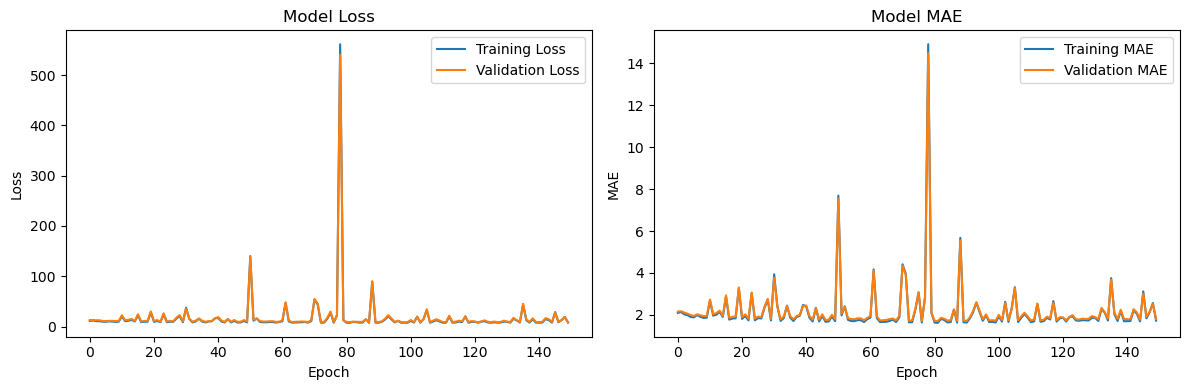

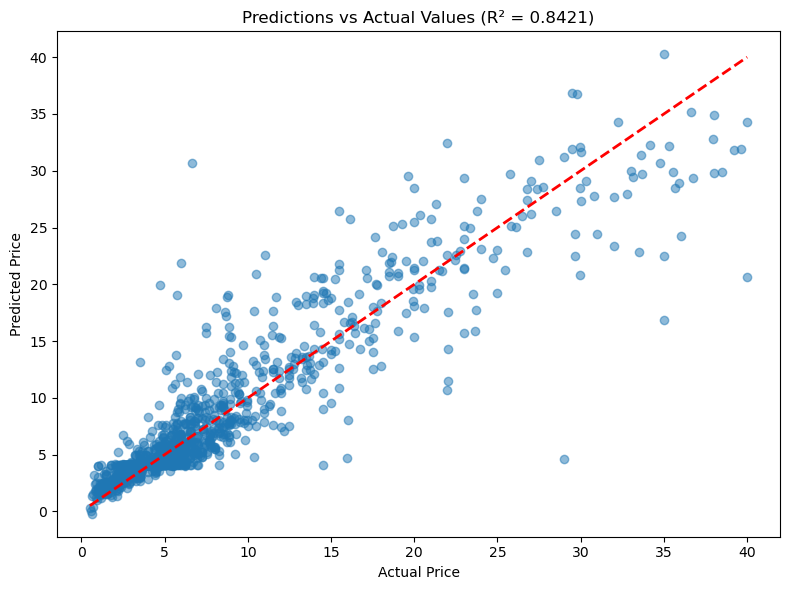

In [19]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss
axes[0].plot(history['loss'], label='Training Loss')
axes[0].plot(history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Plot MAE
axes[1].plot(history['mae'], label='Training MAE')
axes[1].plot(history['val_mae'], label='Validation MAE')
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot predictions vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Predictions vs Actual Values (R² = {r2:.4f})')
plt.tight_layout()
plt.show()



In [21]:
test_df = pd.read_csv('Data2/clean_test_data.csv') 
test_df

,Kilometers_Driven,Mileage,Engine,Power,Seats,Age,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Owner_Type_First,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third
0,13372,19.00,2996.0,362.07,2.0,9,0,False,0,True,True,False,True,0,False,False
1,41000,15.30,2993.0,258.00,5.0,11,0,True,0,False,True,False,True,0,False,False
2,44414,17.90,2143.0,170.00,5.0,10,0,True,0,False,True,False,True,0,False,False
3,36091,12.70,2179.0,187.70,5.0,8,0,True,0,False,True,False,True,0,False,False
4,56000,11.80,2967.0,246.70,5.0,14,0,True,0,False,True,False,True,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,50794,17.90,2143.0,170.00,5.0,9,0,True,0,False,True,False,True,0,False,False
167,8000,12.50,5000.0,488.10,2.0,11,0,False,0,True,True,False,True,0,False,False
168,29091,13.22,2967.0,241.40,5.0,8,0,True,0,False,True,False,True,0,False,False
169,16000,14.69,2993.0,258.00,5.0,10,0,True,0,False,True,False,True,0,False,False


In [40]:
# fitting the data 
testing_data_scaled = scaler.fit_transform(test_df) 

In [52]:
y_test = nn.predict(testing_data_scaled) 
y_test.reshape(-1)
len(y_test)

171

In [54]:
# saving the submmision file
df_old_id = pd.read_csv('Data/test_set_without lables_.csv', sep=';') 

submit = pd.DataFrame({
    'Id': df_old_id['ID'], 
    'Predicted': y_test.flatten()
})
submit.to_csv('Submit/submission.csv', index='False') 

In [55]:
submit

,Id,Predicted
0,134,10.441744
1,168,4.218856
2,172,4.102790
3,191,4.104227
4,216,3.506471
...,...,...
166,5900,4.105152
167,5919,14.135153
168,5927,10.409995
169,5946,6.901937


In [46]:
print(submit.isnull().sum())  # Check for missing values

Id           0
Predicted    0
dtype: int64
